In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["savefig.dpi"] = 300  # Set default dpi to 300 for saving figures

# Price function

In [2]:
def sigmoid(r,s,m,ku,kl):
    return ku - ((ku-kl)/(1+np.exp(-s*(r-m))))

In [3]:
num_rows= 200
ratios= [i/50 for i in range(1,num_rows)]

data_plot=pd.DataFrame({
    'Demand-to-Supply Ratio (M/E)': ratios
}|{i:[sigmoid(r**-1,i,1,0.4,0.08)for r in ratios]for i in np.arange(1,7,step=0.1)})
dfl = pd.melt(data_plot, ['Demand-to-Supply Ratio (M/E)'],var_name='B',value_name="Price in €/kWh")

Text(0.5, 1.0, 'Price Function for Different Values of B')

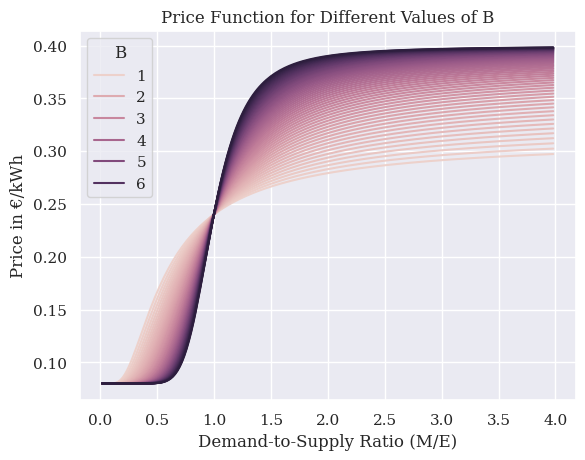

In [4]:
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
sns.lineplot(data=dfl, x='Demand-to-Supply Ratio (M/E)', y='Price in €/kWh', hue='B').set_title("Price Function for Different Values of B")

In [5]:
num_rows= 400
ratios= [i/100 for i in range(1,num_rows)]
data_plot=pd.DataFrame({
    'Demand-to-Supply Ratio (M/E)': ratios
}|{i:[sigmoid(1/r,10,i,0.4,0.08) for r in ratios]for i in np.arange(0.1,1,step=0.01)})
dfl = pd.melt(data_plot, ['Demand-to-Supply Ratio (M/E)'],var_name=r'$\theta$',value_name="Price in €/kWh")

Text(0.5, 1.0, 'Price Function for Different Values of $\\theta$')

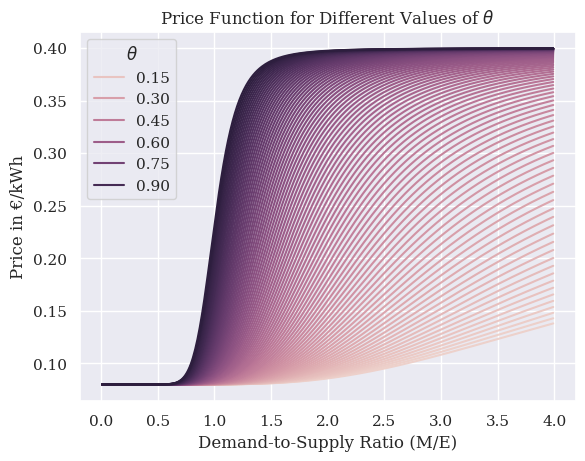

In [6]:
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
sns.lineplot(data=dfl, x='Demand-to-Supply Ratio (M/E)', y='Price in €/kWh', hue=r'$\theta$').set_title(r"Price Function for Different Values of $\theta$")

# Data prep

In [4]:
type_dict={'Time':'int','id':'int'}
data = pd.read_excel("./simulation_results/ammba_results.xlsx")
data["clock"]=pd.to_datetime(data["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
data=data.rename(columns={'clock':'time','pv_gen':'Produced Energy','load':"Used Energy"})
agg = data.groupby(by="Time").agg({'Produced Energy':"sum",'Used Energy':"sum","time":"first","surplus":"sum","demand":"sum"})
dfm = agg.melt("time", var_name='Group', value_name='kWh')


########## AMMBA simulation #############


#calculate buyers utility
buyers = data[data["money_in"] > 0]
data.loc[data["money_in"] > 0,"utility"] = buyers["demand"] * buyers["buy_price"] - (buyers["energy_out"]*buyers["price"] + (buyers["demand"]-buyers["energy_out"])*buyers["buy_price"])

# calculate sellers profit
sellers = data[data["energy_in"] > 0]
data.loc[data["energy_in"]>0,"profit"]= sellers["money_out"] + sellers["energy_out"]*sellers["sell_price"] - (sellers["energy_in"]*sellers["sell_price"])

########## Order Book Simulation #############
o_data = pd.read_excel("./simulation_results/order_book_results.xlsx")
o_data["clock"]=pd.to_datetime(o_data["clock"],format="%H:%M:%S").dt.strftime('%H:%M')
o_data=o_data.rename(columns={'clock':'time','pv_gen':'Produced Energy','load':"Used Energy"})

# calculate energy demand and surplus
o_data["demand"] = (o_data["Used Energy"] - o_data["Produced Energy"]).apply(lambda x: max(x,0))
o_data["surplus"] = (o_data["Produced Energy"]- o_data["Used Energy"]).apply(lambda x: max(x,0))

#calculate buyers utility
o_buyers = o_data[o_data["money_in"] > 0]
o_data.loc[o_data["money_in"] > 0,"utility"] = o_buyers["demand"] * o_buyers["buy_price"] - (o_buyers["money_out"] + (o_buyers["demand"]-o_buyers["energy_out"]*o_buyers["buy_price"]))

# calculate sellers profit
o_sellers = o_data[o_data["energy_in"] > 0]
o_data.loc[o_data["energy_in"]>0,"profit"]= o_sellers["money_out"] + o_sellers["energy_out"]*o_sellers["sell_price"] - (o_sellers["energy_in"]*o_sellers["sell_price"])

# Data vis

## Total damnd and supply

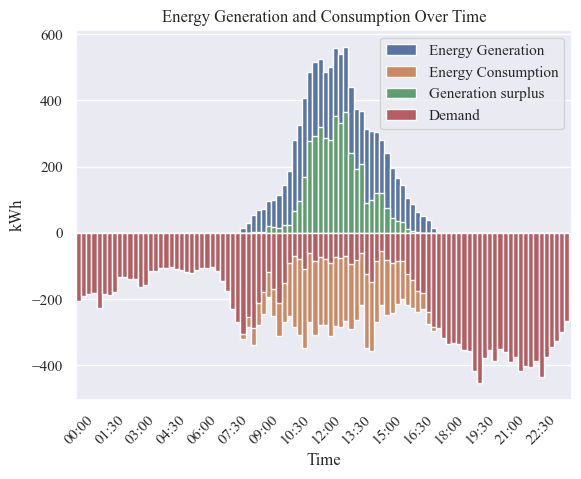

In [5]:
agg1 = agg.copy()
agg1["Used Energy"] = -agg1["Used Energy"]
agg1["demand"] = -agg1["demand"]
dfm1 = agg1.melt("time", var_name='Group', value_name='kWh')
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
sns.set_theme(rc={'font.family':'serif', 'font.serif':'Times New Roman'},style="darkgrid")
plot = sns.barplot(data=dfm1,x="time",y="kWh",hue="Group",dodge=False,width=1)
legend_handles, _= plot.get_legend_handles_labels()
plot.legend(legend_handles, ['Energy Generation',"Energy Consumption","Generation surplus","Demand"])
plot.set_xticks(np.arange(0, 97, 6))
plot.set(xlabel ="Time", ylabel = "kWh", title ='Energy Generation and Consumption Over Time',label=False)
x = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)
fig= plot.get_figure()
fig.savefig("./Images/Generation and Consumption.png")

In [31]:
len((agg1[agg1["surplus"]>0]))

36

<Axes: xlabel='ID', ylabel='Time'>

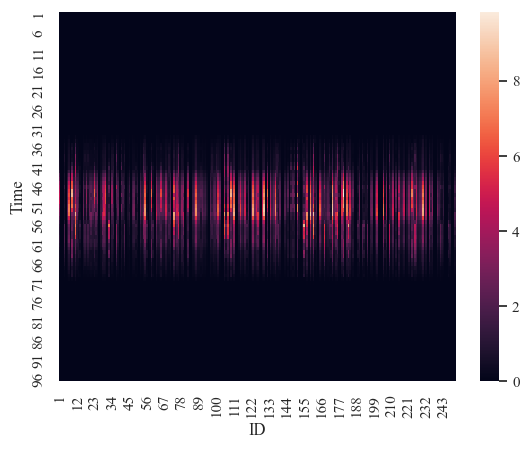

In [21]:
map = data.pivot(index='Time',columns="ID",values="Produced Energy")
sns.heatmap(map)

## Buy Price vis

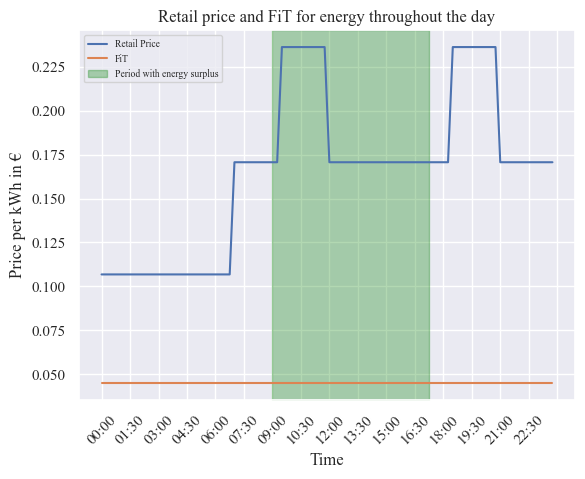

In [6]:
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
agg = data.groupby("Time").agg({"surplus":"sum","demand":"sum","buy_price":"mean","sell_price":"mean","time":"min"})
agg["supply_demand_ratio"]=agg["surplus"]/agg["demand"]
dfm2 = agg.melt(id_vars="time",value_vars=["buy_price","sell_price"],value_name="vals",var_name="x")
plot = sns.lineplot(data=dfm2,x="time",y="vals",hue="x")

#ax2 = plt.twinx()
#plot= sns.lineplot(data=agg,x="time",y="supply_demand_ratio",ax=ax2)
plot.set_xticks(np.arange(0, 97, 6))
plot.set(xlabel ="Time", ylabel = "Price per kWh in €", title ='Retail price and FiT for energy throughout the day',label=False)
x = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)
plot.fill_between([36,69],0,1,transform=plot.get_xaxis_transform(),color="green",alpha=0.3,label="Period with energy surplus")
legend_handles, _= plot.get_legend_handles_labels()
plot.legend(legend_handles, ["Retail Price",'FiT',"Period with energy surplus"],loc=2,fontsize="xx-small")
fig= plot.get_figure()
fig.savefig("./Images/buy prices.png")

In [9]:
agg["supply_demand_ratio"] = agg["surplus"]/agg["demand"]
agg[agg["surplus"]>0]["supply_demand_ratio"].mean()

np.float64(1.4941448558285344)

# AMMBA vis

## Utility vs Profit

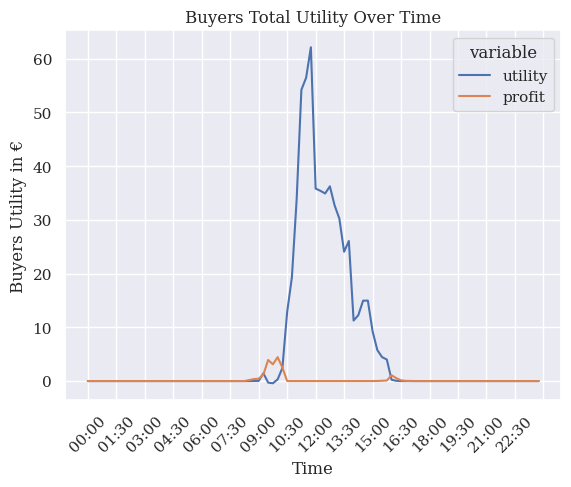

In [48]:
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
grp= data.groupby("Time").agg({"time":"min","utility":"sum","profit":"sum"})
grp=grp.melt("time")
plot = sns.lineplot(data=grp,x="time",y="value",hue="variable")
plot.set(xlabel ="Time", ylabel = "Buyers Utility in €", title ='Buyers Total Utility Over Time')
plot.set_xticks(np.arange(0, 97, 6))
x = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)

## Price over time

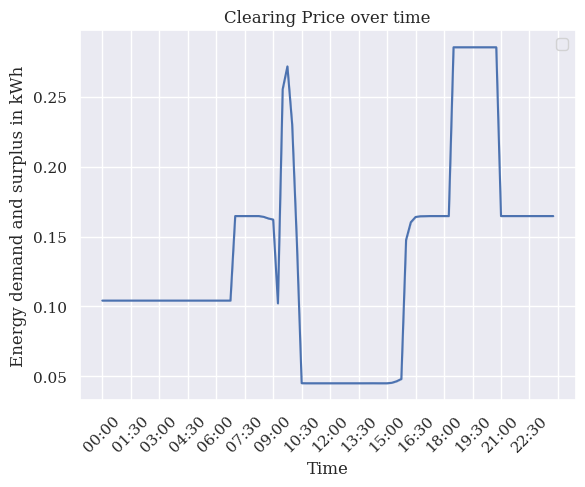

In [49]:
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
#zoomed = data[data["Time"] > 31 and data["Time"] < 73]
plot = sns.lineplot(data=data,x="time",y="price",estimator="mean")
legend_handles, _= plot.get_legend_handles_labels()
plot.legend(legend_handles, ['Supply',"Demand"], bbox_to_anchor=(1,1))
plot.set_xticks(np.arange(0, 97, 6))
plot.set(xlabel ="Time", ylabel = "Energy demand and surplus in kWh", title ='Clearing Price over time',label=False)
x = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)

## Sold energy vs surplus

In [40]:
grp = data.groupby(by="Time").agg({"surplus":"sum","time":"min"})
grp["traded"]=data[data["demand"]>0].agg({"time":"min","energy_out":"sum"})

# Order Book vis

## Utility vs Profit

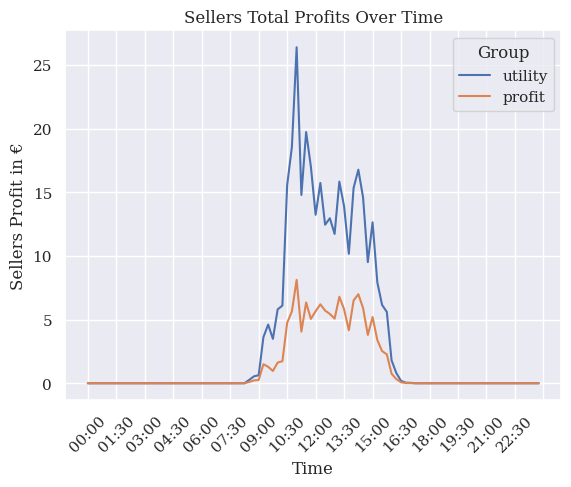

In [15]:
############## order book vis ###############
o_grp_data= o_data.groupby("Time").agg({"time":"min","utility":"sum","profit":"sum"}).melt("time", var_name='Group', value_name='return')
plot = sns.lineplot(data=o_grp_data,x="time",y="return",hue="Group")
plot.set_xticks(np.arange(0, 97, 6))
plot.set(xlabel ="Time", ylabel = "Sellers Profit in €", title ='Sellers Total Profits Over Time')
p = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)



## avg prices

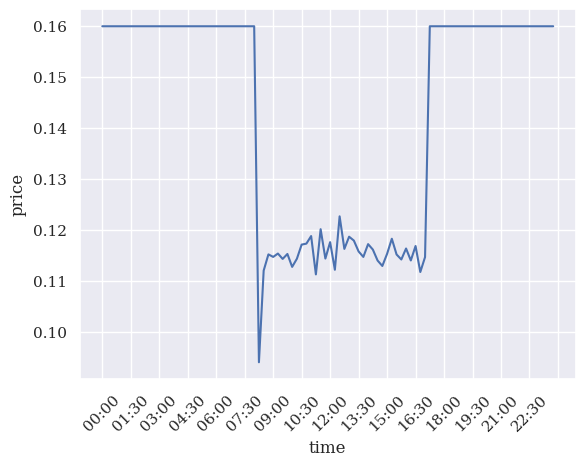

In [23]:
o_price = o_data.groupby("Time").agg({"time":"min","money_out":"sum","energy_out":"sum"})
o_price["price"]=o_price["money_out"]/o_price["energy_out"]
o_price.fillna(0.16,inplace=True)
plot = sns.lineplot(data=o_price,x="time",y="price")
plot.set_xticks(np.arange(0, 97, 6))
p = plot.set_xticklabels(plot.get_xticklabels(), rotation=45)

## Traded Energy vs total produced energy

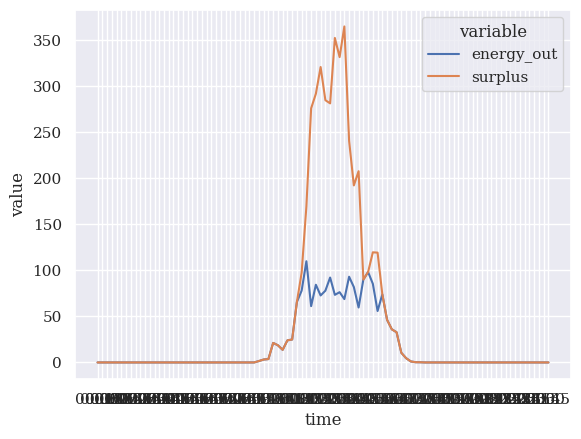

In [37]:
grp = o_data.groupby("Time").agg({"time":"min","energy_out":"sum","surplus":"sum"})
grp = grp.melt("time")
plot = sns.lineplot(data=grp,x="time",y="value",hue="variable")

<Axes: xlabel='time', ylabel='demand'>

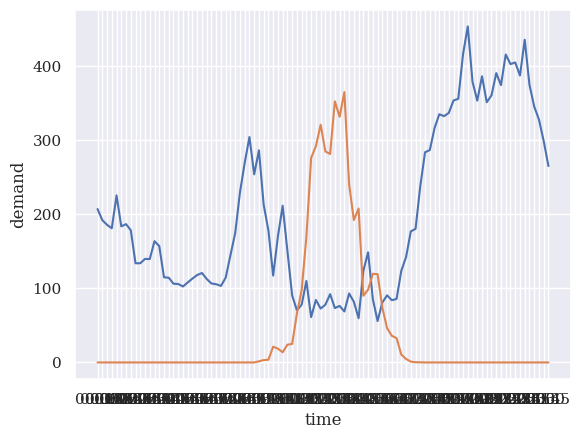

In [ ]:
sns.lineplot(data=grp,x="time",y="demand")
sns.lineplot(data=grp,x="time",y="surplus")